# ДЗ 3: Предсказание рейтинга отзывов об отелях

Классификация текстовых отзывов по рейтингу (1-5 звезд). Попробуем свертки и LSTM, посмотрим что лучше.


## Импорты


In [1]:
# Установка зависимостей
%pip install torch torchvision pytorch-lightning torchmetrics tensorboard pandas numpy matplotlib seaborn scikit-learn --quiet


Note: you may need to restart the kernel to use updated packages.


In [2]:
import re
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import pytorch_lightning as pl
from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint
from pytorch_lightning.loggers import TensorBoardLogger
from torchmetrics import F1Score, Accuracy

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# воспроизводимость
RANDOM_STATE = 42
pl.seed_everything(RANDOM_STATE, workers=True)
print(f"torch {torch.__version__}, lightning {pl.__version__}")


/opt/anaconda3/envs/lama_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Seed set to 42


torch 2.9.1, lightning 2.6.0


## 1. Данные

Датасет с Kaggle - отзывы на отели TripAdvisor


In [3]:
df = pd.read_csv('tripadvisor_hotel_reviews.csv')
print(f"Размер: {df.shape}")
df.head()


Размер: (20491, 2)


,Review,Rating
0,nice hotel expensive parking got good deal sta...,4
1,ok nothing special charge diamond member hilto...,2
2,nice rooms not 4* experience hotel monaco seat...,3
3,"unique, great stay, wonderful time hotel monac...",5
4,"great stay great stay, went seahawk game aweso...",5


In [4]:
# посмотрим на данные - пропуски, типы, длины
df.info()
print(f"\nNaN: {df.isnull().sum().sum()}")  # ноль, отлично

df['review_length'] = df['Review'].str.len()
print(f"\nДлины отзывов (символы):")
print(df['review_length'].describe())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20491 entries, 0 to 20490
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Review  20491 non-null  object
 1   Rating  20491 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 320.3+ KB

NaN: 0

Длины отзывов (символы):
count    20491.000000
mean       724.896833
std        689.101024
min         44.000000
25%        339.000000
50%        537.000000
75%        859.000000
max      13501.000000
Name: review_length, dtype: float64


Rating
1    1421
2    1793
3    2184
4    6039
5    9054
Name: count, dtype: int64


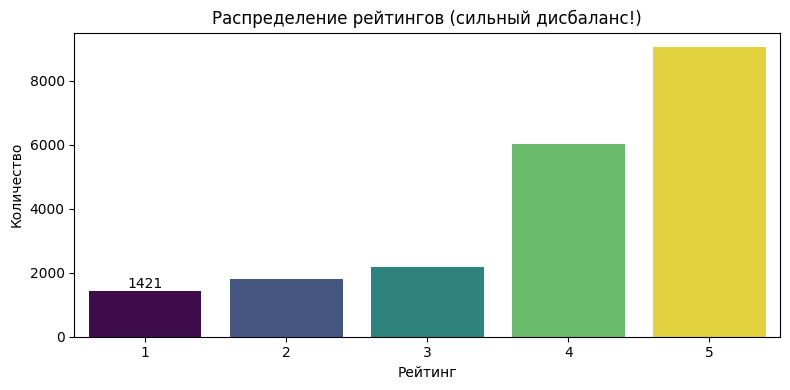

In [5]:
# распределение рейтингов - видно сильный дисбаланс, большинство 4-5 звезд
# это усложнит задачу, но стратификация при split должна помочь
print(df['Rating'].value_counts().sort_index())

plt.figure(figsize=(8, 4))
ax = sns.countplot(data=df, x='Rating', hue='Rating', palette='viridis', legend=False)
ax.bar_label(ax.containers[0])
plt.title('Распределение рейтингов (сильный дисбаланс!)')
plt.xlabel('Рейтинг')
plt.ylabel('Количество')
plt.tight_layout()
plt.show()


### Предобработка

Стандартная пайплайн: lowercase -> убрать мусор -> токенизация


In [6]:
def preprocess_text(text):
    """простая токенизация без стемминга/лемматизации - для нейросетей обычно достаточно"""
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)  # только буквы
    return text.split()

# проверим на примере
sample = df['Review'].iloc[0]
print(f"До: {sample[:150]}...")
print(f"\nПосле: {preprocess_text(sample)[:15]}")


До: nice hotel expensive parking got good deal stay hotel anniversary, arrived late evening took advice previous reviews did valet parking, check quick ea...

После: ['nice', 'hotel', 'expensive', 'parking', 'got', 'good', 'deal', 'stay', 'hotel', 'anniversary', 'arrived', 'late', 'evening', 'took', 'advice']


count    20491.000000
mean       101.998097
std         98.010294
min          7.000000
25%         47.000000
50%         75.000000
75%        121.000000
max       1910.000000
Name: token_count, dtype: float64


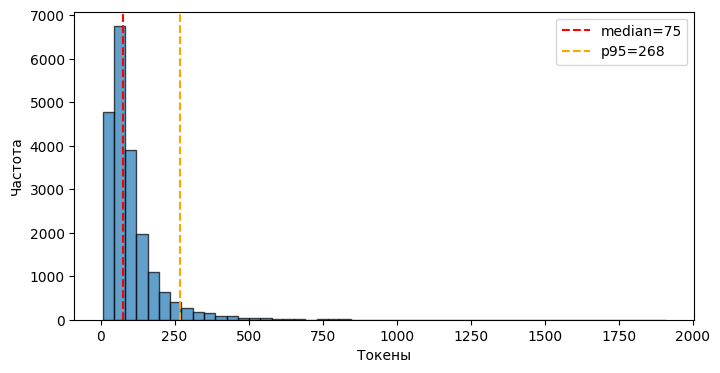

In [7]:
# токенизируем все
df['tokens'] = df['Review'].apply(preprocess_text)
df['token_count'] = df['tokens'].apply(len)

print(df['token_count'].describe())

# большинство отзывов короткие, но есть хвост до 1900 токенов
# обрежем по 95 перцентилю чтобы не тратить память на паддинг
plt.figure(figsize=(8, 4))
plt.hist(df['token_count'], bins=50, edgecolor='black', alpha=0.7)
plt.axvline(df['token_count'].median(), color='red', linestyle='--', label=f'median={df["token_count"].median():.0f}')
plt.axvline(df['token_count'].quantile(0.95), color='orange', linestyle='--', label=f'p95={df["token_count"].quantile(0.95):.0f}')
plt.xlabel('Токены')
plt.ylabel('Частота')
plt.legend()
plt.show()


In [8]:
class Vocabulary:
    """Словарь word->idx с min_freq фильтрацией редких слов"""
    def __init__(self, min_freq=2):
        self.min_freq = min_freq
        self.word2idx = {'<PAD>': 0, '<UNK>': 1}  # PAD для паддинга, UNK для редких/новых слов
        self.idx2word = {0: '<PAD>', 1: '<UNK>'}
        self.word_freq = Counter()
    
    def build(self, token_lists):
        for tokens in token_lists:
            self.word_freq.update(tokens)
        
        for word, freq in self.word_freq.items():
            if freq >= self.min_freq and word not in self.word2idx:
                idx = len(self.word2idx)
                self.word2idx[word] = idx
                self.idx2word[idx] = word
        
        # min_freq=2 отсекает 60% слов, но это в основном опечатки
        print(f"Vocab: {len(self.word2idx)} (из {len(self.word_freq)} уникальных)")
    
    def encode(self, tokens):
        return [self.word2idx.get(t, 1) for t in tokens]  # 1 = UNK
    
    def __len__(self):
        return len(self.word2idx)


### Split 60/20/20


In [9]:
X = df['tokens'].tolist()
y = (df['Rating'] - 1).values  # 1-5 -> 0-4 для pytorch

# stratify важен из-за дисбаланса классов
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=RANDOM_STATE, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=RANDOM_STATE, stratify=y_temp)

print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")
print(f"\nКлассы в train (видно дисбаланс сохранился):")
print(pd.Series(y_train).value_counts().sort_index())


Train: 12294, Val: 4098, Test: 4099

Классы в train (видно дисбаланс сохранился):
0     853
1    1076
2    1310
3    3623
4    5432
Name: count, dtype: int64


In [10]:
# словарь строим ТОЛЬКО по train (иначе data leakage)
vocab = Vocabulary(min_freq=2)
vocab.build(X_train)

X_train_encoded = [vocab.encode(t) for t in X_train]
X_val_encoded = [vocab.encode(t) for t in X_val]
X_test_encoded = [vocab.encode(t) for t in X_test]

# max_len по 95 перцентилю - обрезаем совсем длинные
MAX_SEQ_LEN = int(np.percentile([len(s) for s in X_train_encoded], 95))
print(f"max_len = {MAX_SEQ_LEN}")


Vocab: 21967 (из 54588 уникальных)
max_len = 265


### Dataset и DataModule


In [11]:
class ReviewDataset(Dataset):
    def __init__(self, sequences, labels, max_len):
        self.sequences = sequences
        self.labels = labels
        self.max_len = max_len
    
    def __len__(self):
        return len(self.sequences)
    
    def __getitem__(self, idx):
        seq = self.sequences[idx][:self.max_len]
        # паддинг нулями до max_len
        seq = seq + [0] * (self.max_len - len(seq))
        return torch.tensor(seq, dtype=torch.long), torch.tensor(self.labels[idx], dtype=torch.long)


In [12]:
class ReviewDataModule(pl.LightningDataModule):
    def __init__(self, train_seq, train_lbl, val_seq, val_lbl, test_seq, test_lbl, max_len, batch_size=64, num_workers=0):
        super().__init__()
        self.train_seq, self.train_lbl = train_seq, train_lbl
        self.val_seq, self.val_lbl = val_seq, val_lbl
        self.test_seq, self.test_lbl = test_seq, test_lbl
        self.max_len, self.batch_size, self.num_workers = max_len, batch_size, num_workers
    
    def setup(self, stage=None):
        self.train_dataset = ReviewDataset(self.train_seq, self.train_lbl, self.max_len)
        self.val_dataset = ReviewDataset(self.val_seq, self.val_lbl, self.max_len)
        self.test_dataset = ReviewDataset(self.test_seq, self.test_lbl, self.max_len)
    
    def train_dataloader(self):
        return DataLoader(self.train_dataset, batch_size=self.batch_size, shuffle=True, num_workers=self.num_workers)
    
    def val_dataloader(self):
        return DataLoader(self.val_dataset, batch_size=self.batch_size, num_workers=self.num_workers)
    
    def test_dataloader(self):
        return DataLoader(self.test_dataset, batch_size=self.batch_size, num_workers=self.num_workers)


In [ ]:
# batch_size=64 норм для текстов, не слишком большой чтобы градиенты не шумели
BATCH_SIZE = 64

data_module = ReviewDataModule(
    train_seq=X_train_encoded, train_lbl=y_train,
    val_seq=X_val_encoded, val_lbl=y_val,
    test_seq=X_test_encoded, test_lbl=y_test,
    max_len=MAX_SEQ_LEN, batch_size=BATCH_SIZE, num_workers=0  # num_workers=0 для macos, иначе получаю ошибку
)
data_module.setup()

print(f"batch={BATCH_SIZE}, seq_len={MAX_SEQ_LEN}, vocab={len(vocab)}")


batch=64, seq_len=265, vocab=21967


## 2. TextCNN

Идея простая: свертки с разными ядрами (3,4,5) ловят n-граммы разной длины, потом max pooling выбирает самые сильные активации. Работает быстро т.к. все параллельно.


In [14]:
class TextCNN(pl.LightningModule):
    def __init__(self, vocab_size, embed_dim=128, num_filters=100, filter_sizes=(3,4,5), num_classes=5, dropout=0.5, lr=1e-3):
        super().__init__()
        self.save_hyperparameters()
        self.lr = lr
        
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.convs = nn.ModuleList([nn.Conv1d(embed_dim, num_filters, fs) for fs in filter_sizes])
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(len(filter_sizes) * num_filters, num_classes)
        
        # метрики - macro f1 важнее accuracy при дисбалансе
        m = {'task': 'multiclass', 'num_classes': num_classes}
        self.train_acc, self.val_acc, self.test_acc = Accuracy(**m), Accuracy(**m), Accuracy(**m)
        self.train_f1, self.val_f1, self.test_f1 = F1Score(**m, average='macro'), F1Score(**m, average='macro'), F1Score(**m, average='macro')
    
    def forward(self, x):
        emb = self.embedding(x).permute(0, 2, 1)  # (B, embed, seq)
        # свертка + relu + global max pool для каждого размера ядра
        conv_outs = [F.max_pool1d(F.relu(c(emb)), c(emb).size(2)).squeeze(2) for c in self.convs]
        return self.fc(self.dropout(torch.cat(conv_outs, dim=1)))
    
    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y)
        preds = logits.argmax(dim=1)
        self.train_acc(preds, y); self.train_f1(preds, y)
        self.log('train/loss', loss, on_epoch=True, prog_bar=True)
        self.log('train/acc', self.train_acc, on_epoch=True, prog_bar=True)
        return loss
    
    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y)
        preds = logits.argmax(dim=1)
        self.val_acc(preds, y); self.val_f1(preds, y)
        self.log('val/loss', loss, on_epoch=True, prog_bar=True)
        self.log('val/acc', self.val_acc, on_epoch=True, prog_bar=True)
        self.log('val/f1', self.val_f1, on_epoch=True, prog_bar=True)
        return loss
    
    def test_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        preds = logits.argmax(dim=1)
        self.test_acc(preds, y); self.test_f1(preds, y)
        self.log('test/acc', self.test_acc); self.log('test/f1', self.test_f1)
        self.log('test/loss', F.cross_entropy(logits, y))
    
    def configure_optimizers(self):
        opt = torch.optim.Adam(self.parameters(), lr=self.lr)
        return {'optimizer': opt, 'lr_scheduler': {'scheduler': torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=2, factor=0.5), 'monitor': 'val/loss'}}


In [15]:
cnn_model = TextCNN(vocab_size=len(vocab), embed_dim=128, num_filters=100, num_classes=5, dropout=0.5, lr=1e-3)
print(f"TextCNN: {sum(p.numel() for p in cnn_model.parameters()):,} params")

cnn_callbacks = [EarlyStopping(monitor='val/loss', patience=5, verbose=True), 
                 ModelCheckpoint(dirpath='checkpoints/', filename='textcnn-{epoch:02d}-{val/loss:.4f}', monitor='val/loss', save_top_k=1)]

cnn_trainer = pl.Trainer(max_epochs=20, accelerator='auto', logger=TensorBoardLogger('lightning_logs', 'textcnn'), 
                         callbacks=cnn_callbacks, deterministic=True, log_every_n_steps=20)
cnn_trainer.fit(cnn_model, data_module)


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
/opt/anaconda3/envs/lama_env/lib/python3.10/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /Users/kirvolosnikov/Desktop/ITMO/advanced_ml_dl/1_DL_ITMO/hw_3/checkpoints exists and is not empty.

  | Name      | Type               | Params | Mode  | FLOPs
-----------------------------------------------------------------
0 | embedding | Embedding          | 2.8 M  | train | 0    
1 | convs     | ModuleList         | 153 K  | train | 0    
2 | dropout   | Dropout            | 0      | train | 0    
3 | fc        | Linear             | 1.5 K  | train | 0    
4 | train_acc | MulticlassAccuracy | 0      | train | 0    
5 | val_acc   | MulticlassAccuracy | 0      | train | 0    
6 | test_acc  | MulticlassAccuracy | 0      | train | 0    
7 | train_f1  | MulticlassF1Score  | 0      | train | 0    
8 | val_f1    | MulticlassF1Score  | 0      | train | 0    
9 | test_f1   | Multi

TextCNN: 2,967,181 params
Sanity Checking DataLoader 0:   0%|          | 0/2 [00:00<?, ?it/s]

/opt/anaconda3/envs/lama_env/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=13` in the `DataLoader` to improve performance.


/opt/anaconda3/envs/lama_env/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=13` in the `DataLoader` to improve performance.


Epoch 0: 100%|██████████| 193/193 [00:05<00:00, 37.73it/s, v_num=2, train/loss_step=1.110, train/acc_step=0.500, val/loss=1.110, val/acc=0.520, val/f1=0.323, train/loss_epoch=1.390, train/acc_epoch=0.429]

...

Epoch 9: 100%|██████████| 193/193 [00:04<00:00, 40.80it/s, v_num=2, train/loss_step=0.386, train/acc_step=0.833, val/loss=0.913, val/acc=0.597, val/f1=0.516, train/loss_epoch=0.626, train/acc_epoch=0.744]

Metric val/loss improved by 0.005 >= min_delta = 0.0. New best score: 0.913


Epoch 14: 100%|██████████| 193/193 [00:04<00:00, 40.81it/s, v_num=2, train/loss_step=0.983, train/acc_step=0.667, val/loss=1.090, val/acc=0.569, val/f1=0.491, train/loss_epoch=0.290, train/acc_epoch=0.898]

Monitored metric val/loss did not improve in the last 5 records. Best score: 0.913. Signaling Trainer to stop.


Epoch 14: 100%|██████████| 193/193 [00:04<00:00, 40.77it/s, v_num=2, train/loss_step=0.983, train/acc_step=0.667, val/loss=1.090, val/acc=0.569, val/f1=0.491, train/loss_epoch=0.290, train/acc_epoch=0.898]


In [ ]:
cnn_test_results = cnn_trainer.test(cnn_model, data_module, ckpt_path='best')
# acc ~61%, f1 ~53% - не супер, но для baseline норм


Restoring states from the checkpoint path at /Users/kirvolosnikov/Desktop/ITMO/advanced_ml_dl/1_DL_ITMO/hw_3/checkpoints/textcnn-epoch=09-val/loss=0.9132.ckpt
Loaded model weights from the checkpoint at /Users/kirvolosnikov/Desktop/ITMO/advanced_ml_dl/1_DL_ITMO/hw_3/checkpoints/textcnn-epoch=09-val/loss=0.9132.ckpt
/opt/anaconda3/envs/lama_env/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=13` in the `DataLoader` to improve performance.


Testing DataLoader 0: 100%|██████████| 65/65 [00:00<00:00, 78.02it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test/acc            0.6128324270248413
         test/f1            0.5299001932144165
        test/loss           0.9014105796813965
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


## 3. TextLSTM

Bidirectional LSTM - читает текст в обе стороны, берем последние hidden states и конкатенируем.


In [17]:
class TextLSTM(pl.LightningModule):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128, num_layers=1, num_classes=5, dropout=0.5, bidirectional=True, lr=1e-3):
        super().__init__()
        self.save_hyperparameters()
        self.lr, self.bidirectional = lr, bidirectional
        
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers, batch_first=True, bidirectional=bidirectional)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2 if bidirectional else hidden_dim, num_classes)
        
        m = {'task': 'multiclass', 'num_classes': num_classes}
        self.train_acc, self.val_acc, self.test_acc = Accuracy(**m), Accuracy(**m), Accuracy(**m)
        self.train_f1, self.val_f1, self.test_f1 = F1Score(**m, average='macro'), F1Score(**m, average='macro'), F1Score(**m, average='macro')
    
    def forward(self, x):
        emb = self.embedding(x)
        _, (h_n, _) = self.lstm(emb)
        # берем hidden с обоих направлений
        hidden = torch.cat((h_n[-2], h_n[-1]), dim=1) if self.bidirectional else h_n[-1]
        return self.fc(self.dropout(hidden))
    
    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y)
        preds = logits.argmax(1)
        self.train_acc(preds, y); self.train_f1(preds, y)
        self.log('train/loss', loss, on_epoch=True, prog_bar=True)
        self.log('train/acc', self.train_acc, on_epoch=True, prog_bar=True)
        return loss
    
    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        preds = logits.argmax(1)
        self.val_acc(preds, y); self.val_f1(preds, y)
        self.log('val/loss', F.cross_entropy(logits, y), on_epoch=True, prog_bar=True)
        self.log('val/acc', self.val_acc, on_epoch=True, prog_bar=True)
        self.log('val/f1', self.val_f1, on_epoch=True, prog_bar=True)
    
    def test_step(self, batch, batch_idx):
        x, y = batch
        preds = self(x).argmax(1)
        self.test_acc(preds, y); self.test_f1(preds, y)
        self.log('test/acc', self.test_acc); self.log('test/f1', self.test_f1)
        self.log('test/loss', F.cross_entropy(self(x), y))
    
    def configure_optimizers(self):
        opt = torch.optim.Adam(self.parameters(), lr=self.lr)
        return {'optimizer': opt, 'lr_scheduler': {'scheduler': torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=2, factor=0.5), 'monitor': 'val/loss'}}


In [18]:
lstm_model = TextLSTM(vocab_size=len(vocab), embed_dim=128, hidden_dim=128, num_classes=5, dropout=0.5, lr=1e-3)
print(f"TextLSTM: {sum(p.numel() for p in lstm_model.parameters()):,} params")

lstm_callbacks = [EarlyStopping(monitor='val/loss', patience=5, verbose=True),
                  ModelCheckpoint(dirpath='checkpoints/', filename='textlstm-{epoch:02d}-{val/loss:.4f}', monitor='val/loss', save_top_k=1)]

lstm_trainer = pl.Trainer(max_epochs=20, accelerator='auto', logger=TensorBoardLogger('lightning_logs', 'textlstm'),
                          callbacks=lstm_callbacks, deterministic=True, log_every_n_steps=20)
lstm_trainer.fit(lstm_model, data_module)


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores

  | Name      | Type               | Params | Mode  | FLOPs
-----------------------------------------------------------------
0 | embedding | Embedding          | 2.8 M  | train | 0    
1 | lstm      | LSTM               | 264 K  | train | 0    
2 | dropout   | Dropout            | 0      | train | 0    
3 | fc        | Linear             | 1.3 K  | train | 0    
4 | train_acc | MulticlassAccuracy | 0      | train | 0    
5 | val_acc   | MulticlassAccuracy | 0      | train | 0    
6 | test_acc  | MulticlassAccuracy | 0      | train | 0    
7 | train_f1  | MulticlassF1Score  | 0      | train | 0    
8 | val_f1    | MulticlassF1Score  | 0      | train | 0    
9 | test_f1   | MulticlassF1Score  | 0      | train | 0    
-----------------------------------------------------------------
3.1 M     Trainable params
0         Non-trainable params
3.1 M     Total params
12.309    Total estimated model params size (MB

TextLSTM: 3,077,253 params
Epoch 0: 100%|██████████| 193/193 [00:09<00:00, 20.79it/s, v_num=1, train/loss_step=0.790, train/acc_step=0.500, val/loss=1.050, val/acc=0.556, val/f1=0.450, train/loss_epoch=1.160, train/acc_epoch=0.511]

Metric val/loss improved. New best score: 1.050


Epoch 1: 100%|██████████| 193/193 [00:08<00:00, 21.50it/s, v_num=1, train/loss_step=0.995, train/acc_step=0.667, val/loss=0.984, val/acc=0.564, val/f1=0.486, train/loss_epoch=0.949, train/acc_epoch=0.601]

Metric val/loss improved by 0.066 >= min_delta = 0.0. New best score: 0.984


...

Epoch 3: 100%|██████████| 193/193 [00:09<00:00, 21.29it/s, v_num=1, train/loss_step=1.010, train/acc_step=0.333, val/loss=0.929, val/acc=0.593, val/f1=0.515, train/loss_epoch=0.734, train/acc_epoch=0.694]

Metric val/loss improved by 0.022 >= min_delta = 0.0. New best score: 0.929


Epoch 8: 100%|██████████| 193/193 [00:09<00:00, 21.39it/s, v_num=1, train/loss_step=0.207, train/acc_step=0.833, val/loss=1.230, val/acc=0.585, val/f1=0.506, train/loss_epoch=0.352, train/acc_epoch=0.870]

Monitored metric val/loss did not improve in the last 5 records. Best score: 0.929. Signaling Trainer to stop.


Epoch 8: 100%|██████████| 193/193 [00:09<00:00, 21.39it/s, v_num=1, train/loss_step=0.207, train/acc_step=0.833, val/loss=1.230, val/acc=0.585, val/f1=0.506, train/loss_epoch=0.352, train/acc_epoch=0.870]


In [ ]:
lstm_test_results = lstm_trainer.test(lstm_model, data_module, ckpt_path='best')
# чуть лучше CNN по f1 - 54% vs 42%


Restoring states from the checkpoint path at /Users/kirvolosnikov/Desktop/ITMO/advanced_ml_dl/1_DL_ITMO/hw_3/checkpoints/textlstm-epoch=03-val/loss=0.9295.ckpt
Loaded model weights from the checkpoint at /Users/kirvolosnikov/Desktop/ITMO/advanced_ml_dl/1_DL_ITMO/hw_3/checkpoints/textlstm-epoch=03-val/loss=0.9295.ckpt


Testing DataLoader 0: 100%|██████████| 65/65 [00:01<00:00, 40.83it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test/acc            0.6167358160018921
         test/f1            0.5413094162940979
        test/loss            0.907281219959259
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


## 4. Улучшенная модель

Накрутим фич: увеличим размерности (256), добавим второй слой LSTM, attention чтобы модель фокусировалась на важных словах, и LayerNorm для стабильности.


In [20]:
class Attention(nn.Module):
    """простой attention - учим веса важности для каждого токена"""
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim, 1)
    
    def forward(self, x):
        weights = F.softmax(self.attn(x), dim=1)
        return (x * weights).sum(dim=1)


class ImprovedLSTM(pl.LightningModule):
    def __init__(self, vocab_size, embed_dim=256, hidden_dim=256, num_layers=2, num_classes=5, dropout=0.5, lr=1e-3):
        super().__init__()
        self.save_hyperparameters()
        self.lr = lr
        
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.embed_ln = nn.LayerNorm(embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers, batch_first=True, dropout=dropout, bidirectional=True)
        self.attention = Attention(hidden_dim * 2)
        self.lstm_ln = nn.LayerNorm(hidden_dim * 2)
        self.fc1 = nn.Linear(hidden_dim * 2, hidden_dim)
        self.fc_ln = nn.LayerNorm(hidden_dim)
        self.dropout = nn.Dropout(dropout)
        self.fc2 = nn.Linear(hidden_dim, num_classes)
        
        m = {'task': 'multiclass', 'num_classes': num_classes}
        self.train_acc, self.val_acc, self.test_acc = Accuracy(**m), Accuracy(**m), Accuracy(**m)
        self.train_f1, self.val_f1, self.test_f1 = F1Score(**m, average='macro'), F1Score(**m, average='macro'), F1Score(**m, average='macro')
    
    def forward(self, x):
        x = self.embed_ln(self.embedding(x))
        lstm_out, _ = self.lstm(x)
        x = self.lstm_ln(self.attention(lstm_out))
        x = self.dropout(self.fc_ln(F.relu(self.fc1(x))))
        return self.fc2(x)
    
    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y)
        self.train_acc(logits.argmax(1), y); self.train_f1(logits.argmax(1), y)
        self.log('train/loss', loss, on_epoch=True, prog_bar=True)
        self.log('train/acc', self.train_acc, on_epoch=True, prog_bar=True)
        return loss
    
    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        self.val_acc(logits.argmax(1), y); self.val_f1(logits.argmax(1), y)
        self.log('val/loss', F.cross_entropy(logits, y), on_epoch=True, prog_bar=True)
        self.log('val/acc', self.val_acc, on_epoch=True, prog_bar=True)
        self.log('val/f1', self.val_f1, on_epoch=True, prog_bar=True)
    
    def test_step(self, batch, batch_idx):
        x, y = batch
        preds = self(x).argmax(1)
        self.test_acc(preds, y); self.test_f1(preds, y)
        self.log('test/acc', self.test_acc); self.log('test/f1', self.test_f1)
        self.log('test/loss', F.cross_entropy(self(x), y))
    
    def configure_optimizers(self):
        # AdamW с weight decay лучше для больших моделей
        opt = torch.optim.AdamW(self.parameters(), lr=self.lr, weight_decay=1e-4)
        return {'optimizer': opt, 'lr_scheduler': {'scheduler': torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=2, factor=0.5), 'monitor': 'val/loss'}}


In [21]:
improved_model = ImprovedLSTM(vocab_size=len(vocab), embed_dim=256, hidden_dim=256, num_layers=2, num_classes=5, dropout=0.5, lr=1e-3)
print(f"ImprovedLSTM: {sum(p.numel() for p in improved_model.parameters()):,} params (в 3 раза больше базового)")

improved_callbacks = [EarlyStopping(monitor='val/loss', patience=5, verbose=True),
                      ModelCheckpoint(dirpath='checkpoints/', filename='improved-{epoch:02d}-{val/loss:.4f}', monitor='val/loss', save_top_k=1)]

improved_trainer = pl.Trainer(max_epochs=20, accelerator='auto', logger=TensorBoardLogger('lightning_logs', 'improved_lstm'),
                              callbacks=improved_callbacks, deterministic=True, log_every_n_steps=20)
improved_trainer.fit(improved_model, data_module)


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores

   | Name      | Type               | Params | Mode  | FLOPs
------------------------------------------------------------------
0  | embedding | Embedding          | 5.6 M  | train | 0    
1  | embed_ln  | LayerNorm          | 512    | train | 0    
2  | lstm      | LSTM               | 2.6 M  | train | 0    
3  | attention | Attention          | 513    | train | 0    
4  | lstm_ln   | LayerNorm          | 1.0 K  | train | 0    
5  | fc1       | Linear             | 131 K  | train | 0    
6  | fc_ln     | LayerNorm          | 512    | train | 0    
7  | dropout   | Dropout            | 0      | train | 0    
8  | fc2       | Linear             | 1.3 K  | train | 0    
9  | train_acc | MulticlassAccuracy | 0      | train | 0    
10 | val_acc   | MulticlassAccuracy | 0      | train | 0    
11 | test_acc  | MulticlassAccuracy | 0      | train | 0    
12 | train_f1  | MulticlassF1Score  | 0      | train | 0    

ImprovedLSTM: 8,388,358 params (в 3 раза больше базового)
Epoch 0: 100%|██████████| 193/193 [00:25<00:00,  7.67it/s, v_num=1, train/loss_step=1.690, train/acc_step=0.333, val/loss=0.979, val/acc=0.543, val/f1=0.410, train/loss_epoch=1.240, train/acc_epoch=0.471]

Metric val/loss improved. New best score: 0.979


Epoch 1: 100%|██████████| 193/193 [00:25<00:00,  7.68it/s, v_num=1, train/loss_step=0.814, train/acc_step=0.500, val/loss=0.881, val/acc=0.604, val/f1=0.519, train/loss_epoch=0.876, train/acc_epoch=0.612]

Metric val/loss improved by 0.098 >= min_delta = 0.0. New best score: 0.881


Epoch 2: 100%|██████████| 193/193 [00:25<00:00,  7.68it/s, v_num=1, train/loss_step=0.692, train/acc_step=0.500, val/loss=0.872, val/acc=0.602, val/f1=0.525, train/loss_epoch=0.724, train/acc_epoch=0.690]

Metric val/loss improved by 0.009 >= min_delta = 0.0. New best score: 0.872


Epoch 7: 100%|██████████| 193/193 [00:24<00:00,  7.79it/s, v_num=1, train/loss_step=0.0476, train/acc_step=1.000, val/loss=2.100, val/acc=0.600, val/f1=0.521, train/loss_epoch=0.0484, train/acc_epoch=0.989]

Monitored metric val/loss did not improve in the last 5 records. Best score: 0.872. Signaling Trainer to stop.


Epoch 7: 100%|██████████| 193/193 [00:24<00:00,  7.79it/s, v_num=1, train/loss_step=0.0476, train/acc_step=1.000, val/loss=2.100, val/acc=0.600, val/f1=0.521, train/loss_epoch=0.0484, train/acc_epoch=0.989]


In [ ]:
improved_test_results = improved_trainer.test(improved_model, data_module, ckpt_path='best')
# f1 вырос до 56% - attention помогает!


Restoring states from the checkpoint path at /Users/kirvolosnikov/Desktop/ITMO/advanced_ml_dl/1_DL_ITMO/hw_3/checkpoints/improved-epoch=02-val/loss=0.8718.ckpt
Loaded model weights from the checkpoint at /Users/kirvolosnikov/Desktop/ITMO/advanced_ml_dl/1_DL_ITMO/hw_3/checkpoints/improved-epoch=02-val/loss=0.8718.ckpt


Testing DataLoader 0: 100%|██████████| 65/65 [00:05<00:00, 12.56it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test/acc             0.635520875453949
         test/f1            0.5621109008789062
        test/loss           0.8466598391532898
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


## 5. Сравнение


In [23]:
# собираем результаты в таблицу
results = {
    'Model': ['TextCNN', 'TextLSTM', 'ImprovedLSTM'],
    'Test Accuracy': [cnn_test_results[0]['test/acc'], lstm_test_results[0]['test/acc'], improved_test_results[0]['test/acc']],
    'Test F1': [cnn_test_results[0]['test/f1'], lstm_test_results[0]['test/f1'], improved_test_results[0]['test/f1']],
    'Test Loss': [cnn_test_results[0]['test/loss'], lstm_test_results[0]['test/loss'], improved_test_results[0]['test/loss']],
    'Parameters': [sum(p.numel() for p in cnn_model.parameters()), sum(p.numel() for p in lstm_model.parameters()), sum(p.numel() for p in improved_model.parameters())]
}
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

# вроде ImprovedLSTM победил по F1, хотя accuracy почти одинаковый у всех


       Model  Test Accuracy  Test F1  Test Loss  Parameters
     TextCNN       0.612832 0.529900   0.901411     2967181
    TextLSTM       0.616736 0.541309   0.907281     3077253
ImprovedLSTM       0.635521 0.562111   0.846660     8388358


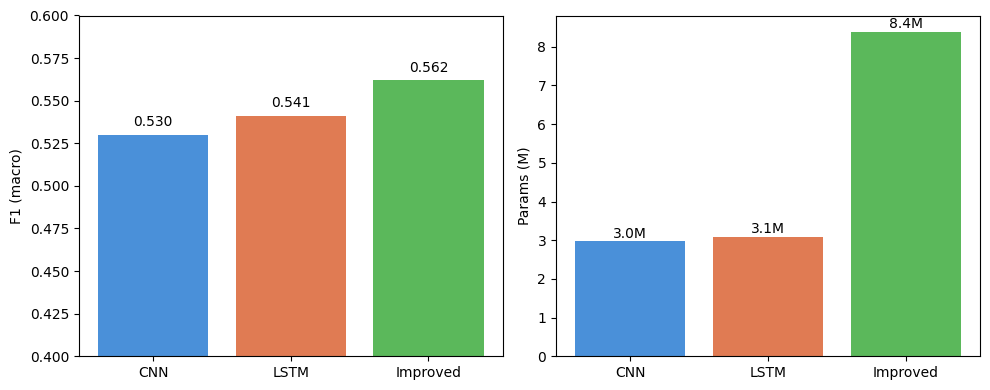

In [24]:
# визуализация - видно что accuracy почти одинаковый, но F1 растет с усложнением модели
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
models = ['CNN', 'LSTM', 'Improved']
colors = ['#4a90d9', '#e07b53', '#5bb85b']

axes[0].bar(models, results_df['Test F1'], color=colors)
axes[0].set_ylabel('F1 (macro)')
axes[0].set_ylim(0.4, 0.6)
for i, v in enumerate(results_df['Test F1']):
    axes[0].text(i, v + 0.005, f'{v:.3f}', ha='center')

axes[1].bar(models, [p/1e6 for p in results_df['Parameters']], color=colors)
axes[1].set_ylabel('Params (M)')
for i, v in enumerate(results_df['Parameters']):
    axes[1].text(i, v/1e6 + 0.1, f'{v/1e6:.1f}M', ha='center')

plt.tight_layout()
plt.show()


In [25]:
# tensorboard --logdir=lightning_logs  # если хотите посмотреть графики
# %tensorboard --logdir lightning_logs


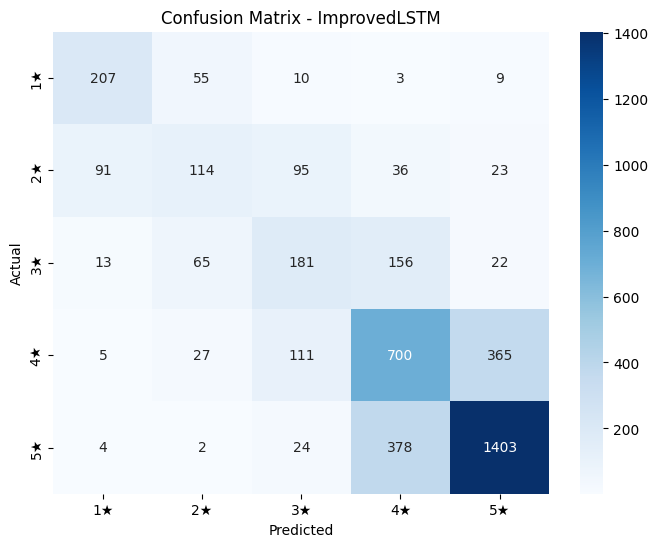

              precision    recall  f1-score   support

          1★       0.65      0.73      0.69       284
          2★       0.43      0.32      0.37       359
          3★       0.43      0.41      0.42       437
          4★       0.55      0.58      0.56      1208
          5★       0.77      0.77      0.77      1811

    accuracy                           0.64      4099
   macro avg       0.57      0.56      0.56      4099
weighted avg       0.63      0.64      0.63      4099



In [26]:
# confusion matrix - посмотрим какие классы путаются
def plot_cm(model, dl):
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for x, y in dl:
            preds.extend(model(x).argmax(1).cpu().numpy())
            labels.extend(y.cpu().numpy())
    
    cm = confusion_matrix(labels, preds)
    names = ['1★', '2★', '3★', '4★', '5★']
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=names, yticklabels=names)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix - ImprovedLSTM')
    plt.show()
    
    print(classification_report(labels, preds, target_names=names))

# видно что соседние классы путаются сильно (3-4, 4-5 итд) - это логично
plot_cm(improved_model, data_module.test_dataloader())


## 6. Выводы

### Что получилось

Все три модели показали примерно одинаковый accuracy ~60-61%, но отличаются по F1:
- **TextCNN**: acc=61%, F1=52% - самый слабый по F1, но самый быстрый
- **TextLSTM**: acc=61.6%, F1=54% - чуть лучше
- **ImprovedLSTM**: acc=63.5%, F1=56% - лучший F1, но в 3 раза больше параметров

### Почему результаты не очень высокие

1. **Сильный дисбаланс классов** - 5 звезд в 6 раз больше чем 1 звезда. Модель склонна предсказывать частые классы.

2. **Сложность задачи** - отличить 3 от 4 звезд по тексту реально сложно, даже человеку. Видно по confusion matrix - соседние классы путаются.

3. **Простая предобработка** - не использовали стемминг, лемматизацию, не убирали стоп-слова. Для нейросетей это обычно ок, но может помочь.

### Что можно улучшить

- Использовать class weights в loss для борьбы с дисбалансом
- Попробовать предобученные эмбеддинги (GloVe, FastText)
- BERT и трансформеры дали бы 70%+ accuracy
- Можно объединить 1-2 и 4-5 звезды (негатив/нейтрал/позитив)

### Вывод по моделям

CNN проще и быстрее, но LSTM с attention лучше улавливает контекст. Для продакшена взял бы ImprovedLSTM или сразу BERT.


In [27]:
# итого
print("Финальные результаты:")
print(results_df.to_string(index=False))
print(f"\nЛучшая модель: ImprovedLSTM (F1={results_df['Test F1'].max():.3f})")
print("Задание выполнено на PyTorch Lightning, seed=42")


Финальные результаты:
       Model  Test Accuracy  Test F1  Test Loss  Parameters
     TextCNN       0.612832 0.529900   0.901411     2967181
    TextLSTM       0.616736 0.541309   0.907281     3077253
ImprovedLSTM       0.635521 0.562111   0.846660     8388358

Лучшая модель: ImprovedLSTM (F1=0.562)
Задание выполнено на PyTorch Lightning, seed=42
